In [1]:
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/datasets/adityasuhasbandi/historical-data/historical_data.csv
/kaggle/input/datasets/adityasuhasbandi/fear-greed-index/fear_greed_index.csv


In [1]:
import pandas as pd

trader = pd.read_csv('/kaggle/input/datasets/adityasuhasbandi/historical-data/historical_data.csv')
fear_greed = pd.read_csv('/kaggle/input/datasets/adityasuhasbandi/fear-greed-index/fear_greed_index.csv')

print(trader.shape)
print(fear_greed.shape)

(211224, 16)
(2644, 4)


In [2]:
print(trader.columns.tolist())
print(fear_greed.columns.tolist())


['Account', 'Coin', 'Execution Price', 'Size Tokens', 'Size USD', 'Side', 'Timestamp IST', 'Start Position', 'Direction', 'Closed PnL', 'Transaction Hash', 'Order ID', 'Crossed', 'Fee', 'Trade ID', 'Timestamp']
['timestamp', 'value', 'classification', 'date']


In [3]:
print(trader.head(3))
print("---")
print(fear_greed.head(3))

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   

   Size Tokens  Size USD Side     Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY  02-12-2024 22:50        0.000000       Buy   
1        16.00    127.68  BUY  02-12-2024 22:50      986.524596       Buy   
2       144.09   1150.63  BUY  02-12-2024 22:50     1002.518996       Buy   

   Closed PnL                                   Transaction Hash     Order ID  \
0         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
1         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   
2         0.0  0xec09451986a1874e3a980418412fcd0201f500c95bac...  52017706630   

   Crossed       Fee      Trade ID     Timestamp  
0     True  0.345404  8.95

In [4]:
print(trader['Timestamp IST'].dtype)
print(fear_greed['date'].dtype)
print(trader['Timestamp IST'].head(3))
print(fear_greed['date'].head(3))

object
object
0    02-12-2024 22:50
1    02-12-2024 22:50
2    02-12-2024 22:50
Name: Timestamp IST, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
Name: date, dtype: object


In [5]:
trader['date'] = pd.to_datetime(trader['Timestamp IST'], format='%d-%m-%Y %H:%M').dt.date
fear_greed['date'] = pd.to_datetime(fear_greed['date']).dt.date

print(trader['date'].head(3))
print(fear_greed['date'].head(3))

0    2024-12-02
1    2024-12-02
2    2024-12-02
Name: date, dtype: object
0    2018-02-01
1    2018-02-02
2    2018-02-03
Name: date, dtype: object


In [6]:
print("Trader date range:", trader['date'].min(), "to", trader['date'].max())
print("Fear/Greed date range:", fear_greed['date'].min(), "to", fear_greed['date'].max())

Trader date range: 2023-05-01 to 2025-05-01
Fear/Greed date range: 2018-02-01 to 2025-05-02


In [7]:
df = pd.merge(trader, fear_greed[['date', 'value', 'classification']], on='date', how='left')
print(df.shape)
print(df['classification'].value_counts())

(211224, 19)
classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
Name: count, dtype: int64


In [8]:
cols = ['Closed PnL', 'classification', 'Size USD', 'Side']
print(df[cols].isnull().sum())

Closed PnL        0
classification    6
Size USD          0
Side              0
dtype: int64


In [9]:
df = df.dropna(subset=['classification'])
print(df.shape)

(211218, 19)


In [10]:
pnl_by_sentiment = df.groupby('classification')['Closed PnL'].mean().sort_values(ascending=False)
print(pnl_by_sentiment)


classification
Extreme Greed    67.892861
Fear             54.290400
Greed            42.743559
Extreme Fear     34.537862
Neutral          34.307718
Name: Closed PnL, dtype: float64


In [11]:
df['is_win'] = df['Closed PnL'] > 0
win_rate = df.groupby('classification')['is_win'].mean().sort_values(ascending=False)
print(win_rate)

classification
Extreme Greed    0.464943
Fear             0.420768
Neutral          0.396991
Greed            0.384828
Extreme Fear     0.370607
Name: is_win, dtype: float64


In [12]:
size_by_sentiment = df.groupby('classification')['Size USD'].mean().sort_values(ascending=False)
print(size_by_sentiment)

classification
Fear             7816.109931
Greed            5736.884375
Extreme Fear     5349.731843
Neutral          4782.732661
Extreme Greed    3112.251565
Name: Size USD, dtype: float64


In [13]:
trade_count = df.groupby('classification').size().sort_values(ascending=False)
print(trade_count)

classification
Fear             61837
Greed            50303
Extreme Greed    39992
Neutral          37686
Extreme Fear     21400
dtype: int64


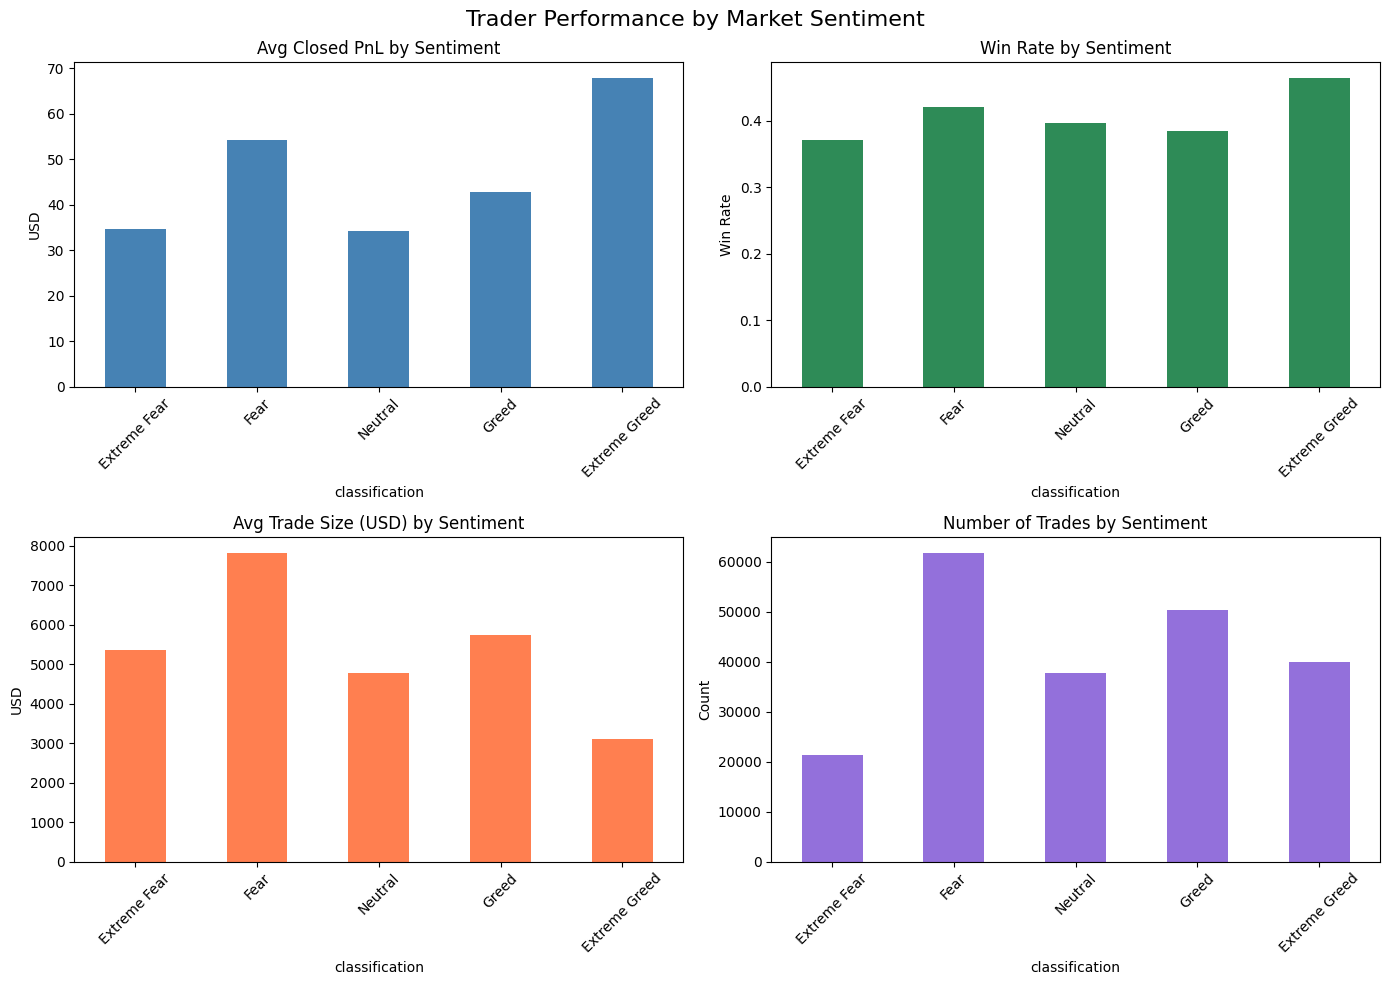

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns

order = ['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Trader Performance by Market Sentiment', fontsize=16)

# Avg PnL
pnl_by_sentiment[order].plot(kind='bar', ax=axes[0,0], color='steelblue')
axes[0,0].set_title('Avg Closed PnL by Sentiment')
axes[0,0].set_ylabel('USD')
axes[0,0].tick_params(axis='x', rotation=45)

# Win Rate
win_rate[order].plot(kind='bar', ax=axes[0,1], color='seagreen')
axes[0,1].set_title('Win Rate by Sentiment')
axes[0,1].set_ylabel('Win Rate')
axes[0,1].tick_params(axis='x', rotation=45)

# Avg Size USD
size_by_sentiment[order].plot(kind='bar', ax=axes[1,0], color='coral')
axes[1,0].set_title('Avg Trade Size (USD) by Sentiment')
axes[1,0].set_ylabel('USD')
axes[1,0].tick_params(axis='x', rotation=45)

# Trade Count
trade_count[order].plot(kind='bar', ax=axes[1,1], color='mediumpurple')
axes[1,1].set_title('Number of Trades by Sentiment')
axes[1,1].set_ylabel('Count')
axes[1,1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

In [15]:
side_sentiment = df.groupby(['classification', 'Side']).size().unstack()
side_sentiment_pct = side_sentiment.div(side_sentiment.sum(axis=1), axis=0)
print(side_sentiment_pct[order])

KeyError: "None of [Index(['Extreme Fear', 'Fear', 'Neutral', 'Greed', 'Extreme Greed'], dtype='object', name='Side')] are in the [columns]"

In [16]:
print(df['Side'].value_counts())

Side
SELL    108528
BUY     102690
Name: count, dtype: int64


In [17]:
side_sentiment = df.groupby(['classification', 'Side']).size().unstack()
side_sentiment_pct = side_sentiment.div(side_sentiment.sum(axis=1), axis=0)
print(side_sentiment_pct.loc[order])

Side                 BUY      SELL
classification                    
Extreme Fear    0.510981  0.489019
Fear            0.489513  0.510487
Neutral         0.503343  0.496657
Greed           0.488559  0.511441
Extreme Greed   0.448590  0.551410


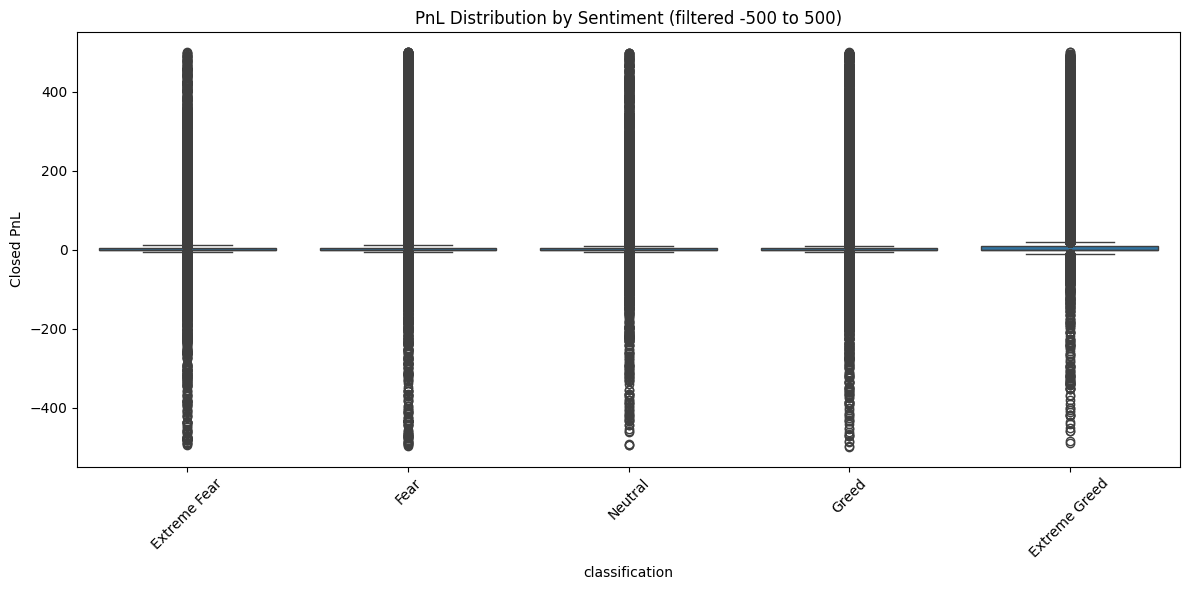

In [18]:
plt.figure(figsize=(12, 6))
df_filtered = df[df['Closed PnL'].between(-500, 500)]  # remove extreme outliers for visibility
sns.boxplot(data=df_filtered, x='classification', y='Closed PnL', order=order)
plt.title('PnL Distribution by Sentiment (filtered -500 to 500)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()


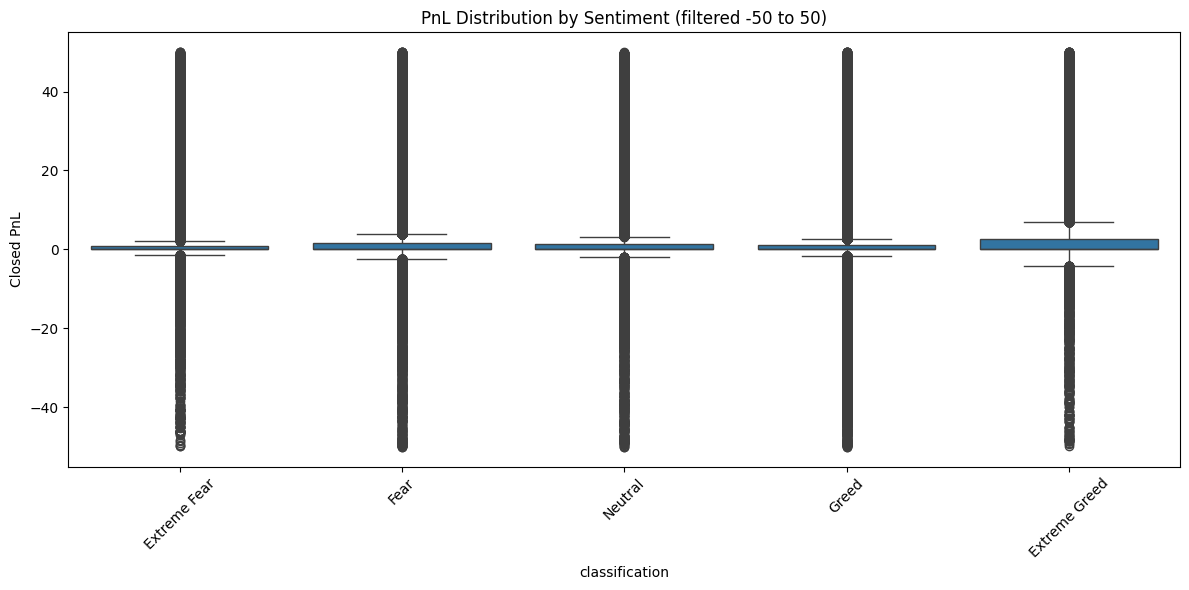

In [19]:
plt.figure(figsize=(12, 6))
df_filtered = df[df['Closed PnL'].between(-50, 50)]
sns.boxplot(data=df_filtered, x='classification', y='Closed PnL', order=order)
plt.title('PnL Distribution by Sentiment (filtered -50 to 50)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [20]:
top_accounts = df.groupby('Account')['Closed PnL'].sum().sort_values(ascending=False).head(10)
print(top_accounts)

Account
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    2.143383e+06
0x083384f897ee0f19899168e3b1bec365f52a9012    1.600230e+06
0xbaaaf6571ab7d571043ff1e313a9609a10637864    9.401638e+05
0x513b8629fe877bb581bf244e326a047b249c4ff1    8.404226e+05
0xbee1707d6b44d4d52bfe19e41f8a828645437aab    8.360806e+05
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4    6.777471e+05
0x72743ae2822edd658c0c50608fd7c5c501b2afbd    4.293556e+05
0x430f09841d65beb3f27765503d0f850b8bce7713    4.165419e+05
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4    3.790954e+05
0x72c6a4624e1dffa724e6d00d64ceae698af892a0    3.605395e+05
Name: Closed PnL, dtype: float64


In [21]:
top_list = top_accounts.index.tolist()
top_df = df[df['Account'].isin(top_list)]
top_sentiment = top_df.groupby(['Account', 'classification']).size().unstack(fill_value=0)
print(top_sentiment[order])


classification                              Extreme Fear   Fear  Neutral  \
Account                                                                    
0x083384f897ee0f19899168e3b1bec365f52a9012           100   1778      421   
0x430f09841d65beb3f27765503d0f850b8bce7713            79    237      134   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4           986   1396      672   
0x513b8629fe877bb581bf244e326a047b249c4ff1           346   5981     2517   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd           509    311       79   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0           221    431       57   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4           316   1664     1464   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23           739   3005     3457   
0xbaaaf6571ab7d571043ff1e313a9609a10637864          4480  12437     4270   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab          5079  12901     8143   

classification                              Greed  Extreme Greed  
Account             

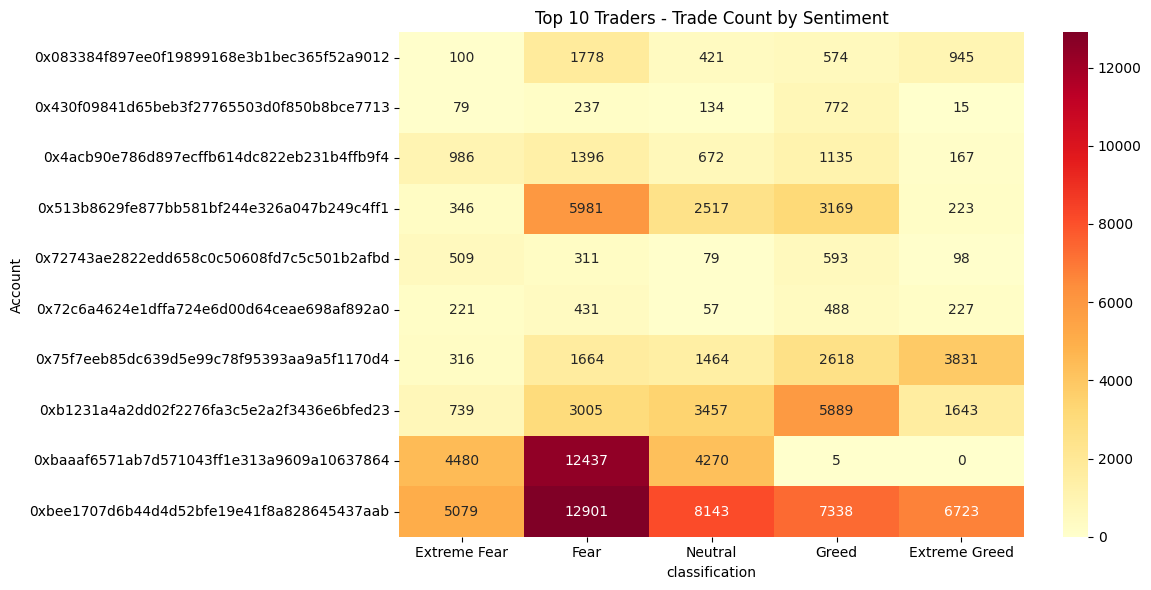

In [22]:
plt.figure(figsize=(12, 6))
sns.heatmap(top_sentiment[order], annot=True, fmt='d', cmap='YlOrRd')
plt.title('Top 10 Traders - Trade Count by Sentiment')
plt.tight_layout()
plt.show()

In [23]:
top_pnl = top_df.groupby(['Account', 'classification'])['Closed PnL'].sum().unstack(fill_value=0)
print(top_pnl[order])

classification                               Extreme Fear          Fear  \
Account                                                                   
0x083384f897ee0f19899168e3b1bec365f52a9012  124769.221441  1.113374e+06   
0x430f09841d65beb3f27765503d0f850b8bce7713       0.000000  5.615052e+03   
0x4acb90e786d897ecffb614dc822eb231b4ffb9f4  166696.399486  2.967817e+05   
0x513b8629fe877bb581bf244e326a047b249c4ff1  -71121.820704  3.671662e+05   
0x72743ae2822edd658c0c50608fd7c5c501b2afbd   33980.000000 -5.821975e+04   
0x72c6a4624e1dffa724e6d00d64ceae698af892a0  198900.561610  1.445143e+05   
0x75f7eeb85dc639d5e99c78f95393aa9a5f1170d4   25672.838055  4.936428e+04   
0xb1231a4a2dd02f2276fa3c5e2a2f3436e6bfed23    9544.906134  9.316516e+04   
0xbaaaf6571ab7d571043ff1e313a9609a10637864  261917.977792  6.208724e+05   
0xbee1707d6b44d4d52bfe19e41f8a828645437aab   30774.092128  5.597880e+04   

classification                                    Neutral          Greed  \
Account                

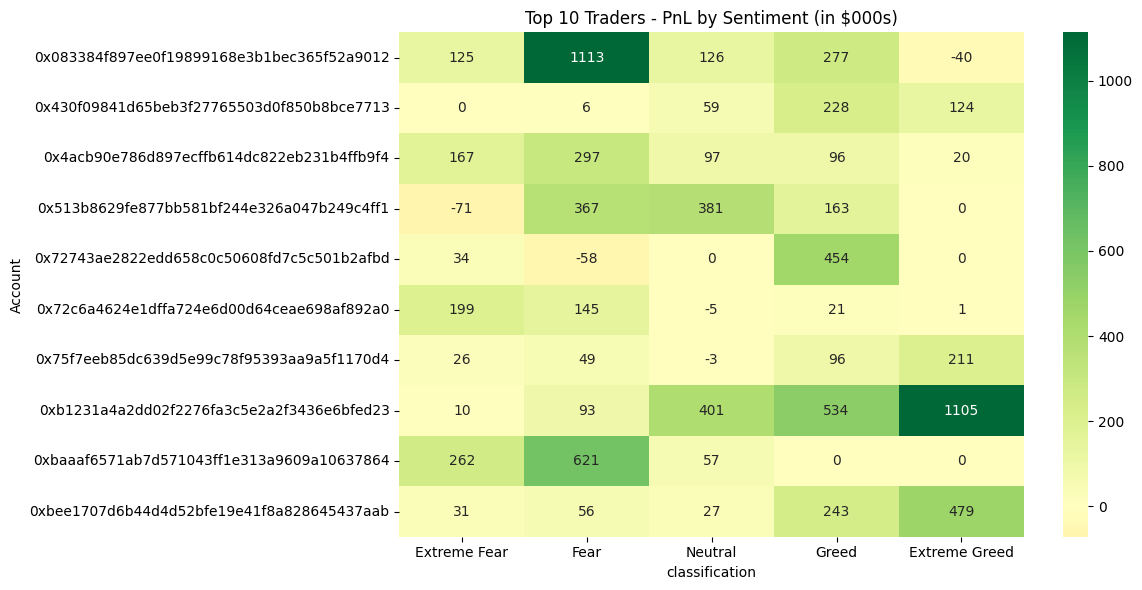

In [24]:
plt.figure(figsize=(12, 6))
sns.heatmap(top_pnl[order]/1000, annot=True, fmt='.0f', cmap='RdYlGn', center=0)
plt.title('Top 10 Traders - PnL by Sentiment (in $000s)')
plt.tight_layout()
plt.show()

In [25]:
coin_sentiment = df.groupby(['classification', 'Coin']).size().unstack(fill_value=0)
top_coins = df['Coin'].value_counts().head(5).index.tolist()
print(coin_sentiment[top_coins].loc[order])

Coin             HYPE   @107   BTC   ETH   SOL
classification                                
Extreme Fear    10278   1519  1765  1393  1878
Fear            27951   5462  9870  2850  3914
Neutral         17324   4210  4753  1317  1400
Greed            6769   8398  7240  3574  1586
Extreme Greed    5683  10403  2436  2024  1913


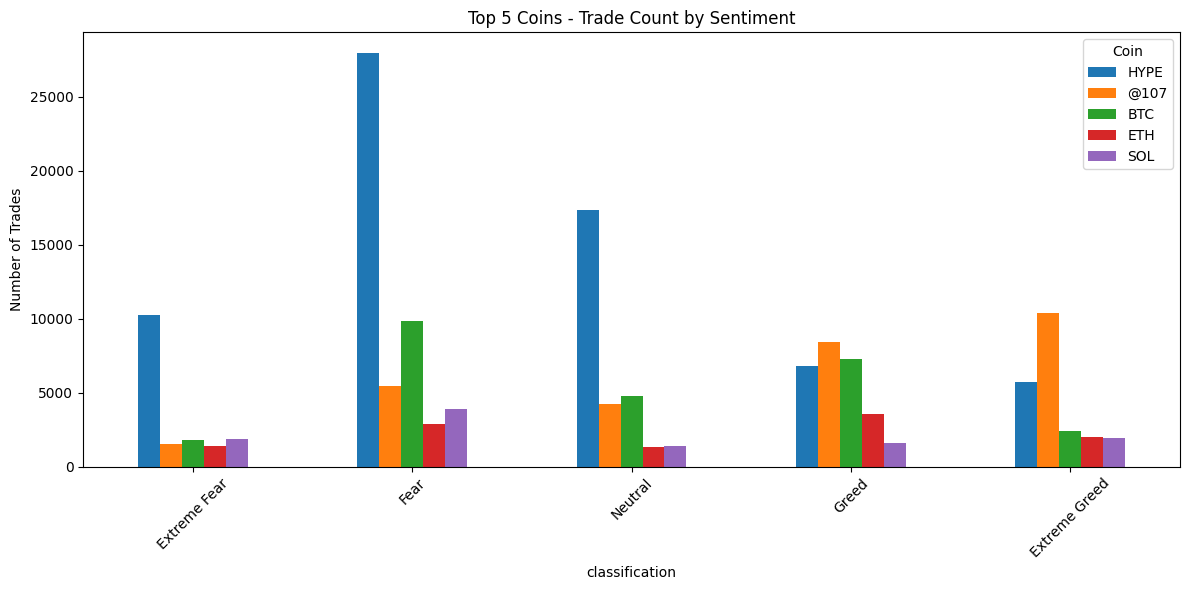

In [26]:
coin_sentiment[top_coins].loc[order].plot(kind='bar', figsize=(12, 6))
plt.title('Top 5 Coins - Trade Count by Sentiment')
plt.ylabel('Number of Trades')
plt.xticks(rotation=45)
plt.legend(title='Coin')
plt.tight_layout()
plt.show()

In [27]:
coin_pnl = df[df['Coin'].isin(top_coins)].groupby(['classification', 'Coin'])['Closed PnL'].mean().unstack()
print(coin_pnl[top_coins].loc[order])

Coin                 HYPE        @107        BTC         ETH         SOL
classification                                                          
Extreme Fear    46.904438  -89.588788   1.731921  196.927660   56.006126
Fear            30.063552   -2.291257  48.900673  236.864764  189.472224
Neutral         17.322803   52.150107  34.921175   46.753294  216.697282
Greed           24.569012   86.251763  15.949612   98.219366  284.798243
Extreme Greed   28.098989  191.158211  41.413264  -20.758928   19.715593


In [28]:
fear_greed_sorted = fear_greed[['date', 'value', 'classification']].copy()
fear_greed_sorted['date'] = pd.to_datetime(fear_greed_sorted['date'])
fear_greed_sorted = fear_greed_sorted.sort_values('date')
fear_greed_sorted['next_day_classification'] = fear_greed_sorted['classification'].shift(-1)
fear_greed_sorted['prev_day_classification'] = fear_greed_sorted['classification'].shift(1)
print(fear_greed_sorted[['date', 'classification', 'prev_day_classification', 'next_day_classification']].head(5))

        date classification prev_day_classification next_day_classification
0 2018-02-01           Fear                    None            Extreme Fear
1 2018-02-02   Extreme Fear                    Fear                    Fear
2 2018-02-03           Fear            Extreme Fear            Extreme Fear
3 2018-02-04   Extreme Fear                    Fear            Extreme Fear
4 2018-02-05   Extreme Fear            Extreme Fear            Extreme Fear


In [29]:
df['date'] = pd.to_datetime(df['date'])
fear_greed_sorted['date'] = pd.to_datetime(fear_greed_sorted['date'])

df_lag = df.merge(fear_greed_sorted[['date', 'prev_day_classification']], on='date', how='left')

lag_pnl = df_lag.groupby('prev_day_classification')['Closed PnL'].mean().reindex(order)
same_pnl = df.groupby('classification')['Closed PnL'].mean().reindex(order)

comparison = pd.DataFrame({
    'Same Day Sentiment': same_pnl,
    'Previous Day Sentiment': lag_pnl
})
print(comparison)


               Same Day Sentiment  Previous Day Sentiment
Extreme Fear            34.537862               52.185226
Fear                    54.290400               53.405169
Neutral                 34.307718               19.443799
Greed                   42.743559               58.621914
Extreme Greed           67.892861               62.046572


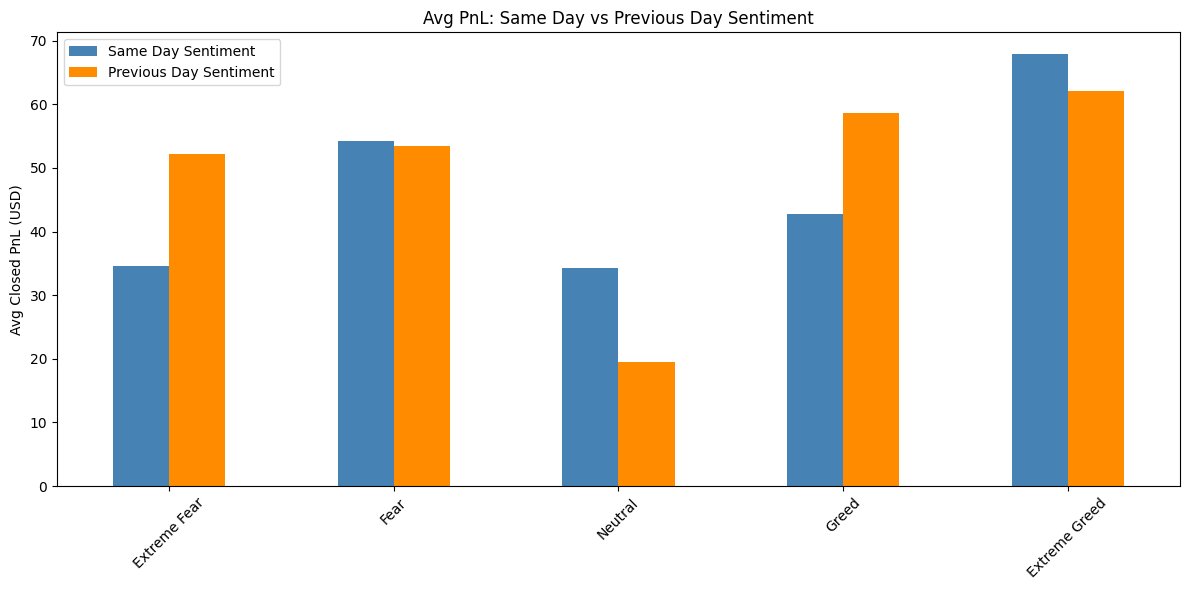

In [30]:
comparison.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'darkorange'])
plt.title('Avg PnL: Same Day vs Previous Day Sentiment')
plt.ylabel('Avg Closed PnL (USD)')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()


In [31]:
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

account_features = df.groupby('Account').agg(
    avg_pnl=('Closed PnL', 'mean'),
    total_pnl=('Closed PnL', 'sum'),
    avg_size=('Size USD', 'mean'),
    win_rate=('is_win', 'mean'),
    trade_count=('Closed PnL', 'count')
).reset_index()

scaler = StandardScaler()
X = scaler.fit_transform(account_features[['avg_pnl', 'avg_size', 'win_rate', 'trade_count']])

kmeans = KMeans(n_clusters=3, random_state=42)
account_features['cluster'] = kmeans.fit_predict(X)

print(account_features.groupby('cluster')[['avg_pnl', 'avg_size', 'win_rate', 'trade_count']].mean())

            avg_pnl      avg_size  win_rate   trade_count
cluster                                                  
0        203.649635  10353.397560  0.439536   4009.000000
1         38.390661   1915.636756  0.379881  20003.833333
2         30.227394   4033.276520  0.381526   3077.642857


In [32]:
cluster_labels = {0: 'High Value', 1: 'High Frequency', 2: 'Mid Tier'}
account_features['cluster_name'] = account_features['cluster'].map(cluster_labels)

df_clustered = df.merge(account_features[['Account', 'cluster_name']], on='Account', how='left')

cluster_sentiment_pnl = df_clustered.groupby(['cluster_name', 'classification'])['Closed PnL'].mean().unstack()
print(cluster_sentiment_pnl[order])

classification  Extreme Fear        Fear     Neutral       Greed  \
cluster_name                                                       
High Frequency     23.915464   24.021253   20.597758   30.224452   
High Value        115.170485  126.432610  112.745871  124.019073   
Mid Tier          -13.429287   42.146702    0.530062  -12.707335   

classification  Extreme Greed  
cluster_name                   
High Frequency      76.981952  
High Value          62.463956  
Mid Tier            47.526355  


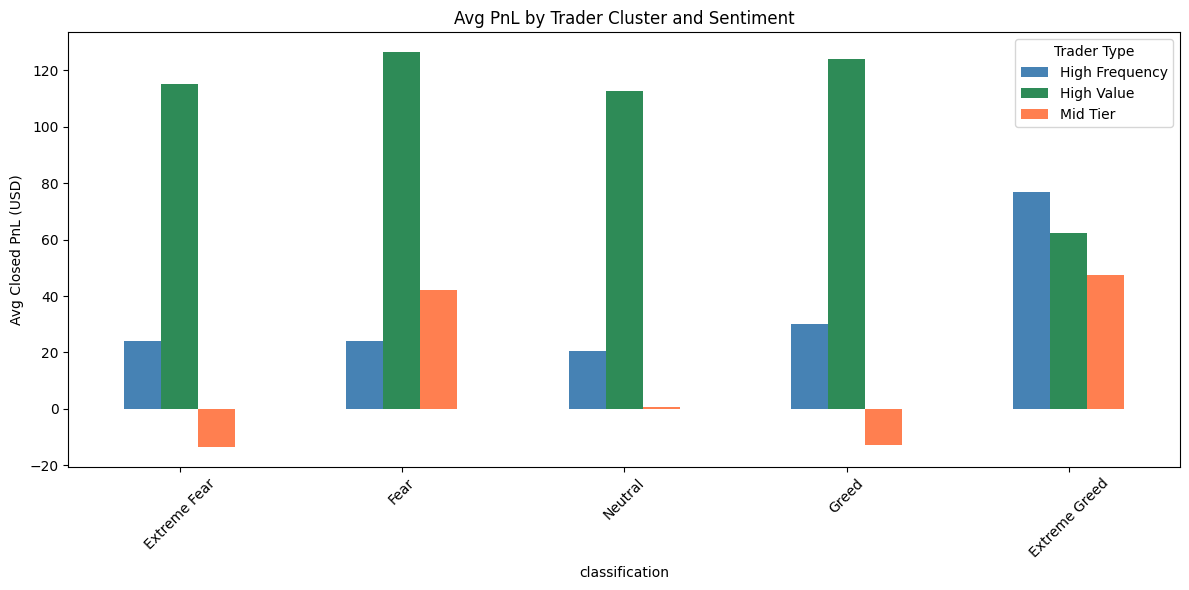

In [33]:
cluster_sentiment_pnl[order].T.plot(kind='bar', figsize=(12, 6), color=['steelblue', 'seagreen', 'coral'])
plt.title('Avg PnL by Trader Cluster and Sentiment')
plt.ylabel('Avg Closed PnL (USD)')
plt.xticks(rotation=45)
plt.legend(title='Trader Type')
plt.tight_layout()
plt.show()